In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load the datasets 
INTERIM_PATH = Path("../data/interim")
PROCESSED_PATH = Path("../data/processed")

snp_data = pd.read_csv(INTERIM_PATH / 'snp500_1mo_cleaned_data.csv', 
                       index_col=0, 
                       parse_dates=True)
ftse_data = pd.read_csv(INTERIM_PATH / 'ftse_1mo_cleaned_data.csv', 
                        index_col=0, 
                        parse_dates=True)
equities_basket = pd.read_csv(INTERIM_PATH / 'equities_1mo_cleaned_data.csv', 
                              parse_dates=['date'])

# Ensure indices also have an explicit 'date' column for merges
snp_data  = snp_data.reset_index().rename(columns={'Date':'date'})
ftse_data = ftse_data.reset_index().rename(columns={'Date':'date'})

print(f"SNP rows:  {len(snp_data)} | FTSE rows: {len(ftse_data)} | Equities rows: {len(equities_basket)}")

SNP rows:  249 | FTSE rows: 249 | Equities rows: 2490


# Compute monthly returns 

In [2]:
def calc_mom_log_return(df, close_col = 'Close', new_col = 'log_return'):
    """
    Calculate the month-over-month return

    - df: DataFrame with price data
    - close_col: Name of the closing price column
    - new_col: Name for the new log return column
    
    Returns:
    - DataFrame with new log return column added
    """
    
    # Get the close of the previous month 
    prev_close = df[close_col].shift(1)
    
    # Calculate the log returns
    df[new_col] = np.log(df[close_col] / prev_close)

    return df

def cal_mom_return_basket(df, group_col = 'ticker', price_col = 'close', new_col = 'log_return'):
    """
    Calculate the month-over-month return

    - df: DataFrame with price data
    - close_col: Name of the closing price column
    - new_col: Name for the new log return column
    
    Returns:
    - DataFrame with a new log return column added
    """
    # Ensure the data set is sorted according to the group column and date
    df = df.sort_values([group_col, 'date']).copy()
    
    # Group the dataset by the ticker name and get the previous close 
    prev = df.groupby(group_col)[price_col].shift(1)
    
    # Perform the log return calculation 
    df[new_col] = np.log(df[price_col]/ prev)
    
    return df

# Compute monthly log returns 

snp_data = calc_mom_log_return(snp_data, close_col='Close', new_col='log_return')
ftse_data = calc_mom_log_return(ftse_data, close_col='Close', new_col='log_return')
equities_basket = cal_mom_return_basket(equities_basket,price_col = 'close', new_col = 'log_return')

# Cleaning

In [3]:
# Check for NaNs 
print('NaNs in S&P500', snp_data['log_return'].isna().sum())
print('NaNs in FTSE100', ftse_data['log_return'].isna().sum())

first_per_ticker = (
    equities_basket.sort_values(["ticker","date"])
                   .groupby("ticker")["log_return"]
                   .head(1).isna().sum()
)
total_nans = equities_basket["log_return"].isna().sum()
print(f"Equities NaNs total: {total_nans} | first-per-ticker: {first_per_ticker} | internal: {total_nans-first_per_ticker}")

# Remove the NaNs 
snp_data  = snp_data.rename(columns={"log_return":"l_bench"}).dropna(subset=["l_bench"])
ftse_data = ftse_data.rename(columns={"log_return":"l_bench"}).dropna(subset=["l_bench"])
equities_basket = equities_basket.rename(columns={"log_return":"l_stock"}).dropna(subset=["l_stock"])

# Recheck NaN after dropping
print('\n=== After Dropping NaNs ===')
print(f"S&P500: {len(snp_data)} rows, {snp_data['l_bench'].isna().sum()} NaNs")
print(f"FTSE100: {len(ftse_data)} rows, {ftse_data['l_bench'].isna().sum()} NaNs")
print(f"Equities: {len(equities_basket)} rows, {equities_basket['l_stock'].isna().sum()} NaNs")



NaNs in S&P500 1
NaNs in FTSE100 1
Equities NaNs total: 10 | first-per-ticker: 10 | internal: 0

=== After Dropping NaNs ===
S&P500: 248 rows, 0 NaNs
FTSE100: 248 rows, 0 NaNs
Equities: 2480 rows, 0 NaNs


In [ ]:
# Save the the data to interim folder 
snp_data[["date","Close","l_bench"]].to_parquet (INTERIM_PATH / "snp500_monthly_with_log_returns.parquet",  index=False)
ftse_data[["date","Close","l_bench"]].to_parquet(INTERIM_PATH / "ftse_monthly_with_log_returns.parquet", index=False)
equities_basket.to_parquet(INTERIM_PATH / "equities_monthly_with_log_returns.parquet", index=False)

In [6]:
# Build benchmark table 
bench_snp500 = snp_data[['date','l_bench']].copy()
bench_snp500['bench'] = '^GSPC'

bench_ftse = ftse_data[['date','l_bench']].copy()
bench_ftse['bench'] = '^FTSE'

# Join tables to create one long benchmark table 
benchmark_df = pd.concat([bench_snp500, bench_ftse],ignore_index=True)

# Match each ticker in the equity basket to the benchmark 
def benchmark_match(ticker):
    if str(ticker).endswith('.L'):
        return "^FTSE"
    else:
        return "^GSPC"

equities_basket["bench"] = equities_basket['ticker'].map(benchmark_match)

In [21]:
# Merge the equities table and benchmark tables 
returns_monthly = equities_basket.merge(benchmark_df, on=["date","bench"], how="inner", validate="many_to_one")
returns_monthly["ex_log"] = returns_monthly["l_stock"] - returns_monthly["l_bench"]

keep_cols = ["date","ticker","bench","l_stock","l_bench","ex_log","close","volume"]
returns_monthly = returns_monthly[keep_cols].sort_values(["ticker","date"])
#returns_monthly.to_parquet(INTERIM_PATH / "returns_monthly_stocks.parquet", index=False)

print("✓ Saved:")
print("  - gspc_monthly_with_log_returns.parquet")
print("  - ftse_monthly_with_log_returns.parquet")
print("  - equities_monthly_with_log_returns.parquet")
print("  - returns_monthly_stocks.parquet (with ex_log)  →", INTERIM_PATH)
print(f"\n{returns_monthly.head()}")

✓ Saved:
  - gspc_monthly_with_log_returns.parquet
  - ftse_monthly_with_log_returns.parquet
  - equities_monthly_with_log_returns.parquet
  - returns_monthly_stocks.parquet (with ex_log)  → ../data/interim

        date ticker  bench   l_stock   l_bench    ex_log     close  \
0 2005-02-28   AAPL  ^GSPC  0.154188  0.018727  0.135461  1.346702   
1 2005-03-31   AAPL  ^GSPC -0.073765 -0.019303 -0.054462  1.250938   
2 2005-04-30   AAPL  ^GSPC -0.144597 -0.020314 -0.124284  1.082525   
3 2005-05-31   AAPL  ^GSPC  0.097677  0.029512  0.068165  1.193600   
4 2005-06-30   AAPL  ^GSPC -0.077092 -0.000143 -0.076949  1.105041   

        volume  
0  21448946400  
1  14675920000  
2  19375518400  
3  12858294400  
4  11327195600  


# Quality Checks 

In [29]:
# ex_log identity
diff = (returns_monthly['ex_log']
        - (returns_monthly['l_stock'] - returns_monthly['l_bench'])).abs().max()
assert diff < 1e-12, f"ex_log mismatch max diff = {diff}"

# No duplicate keys on the benchmark side
assert not benchmark_df.duplicated(['bench','date']).any(), "Duplicate (bench,date) in benchmark table"

# (Optional) centering by bench
print(returns_monthly.groupby('bench')['ex_log'].mean())


bench
^FTSE    0.001057
^GSPC    0.003265
Name: ex_log, dtype: float64


           mean       min       max  count
bench                                     
^FTSE -0.148584 -0.148584 -0.148584      5
^GSPC -0.133668 -0.133668 -0.133668      5

Share of stocks < 0 in Mar-2020: 70.0%


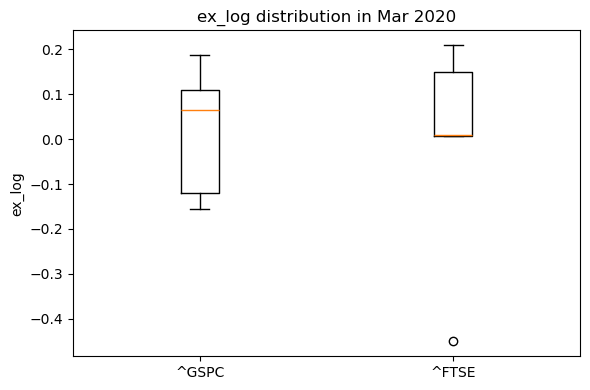

In [35]:
# March 2020 check to see if the data acts as expected (crash and then rebound in April)
m20 = returns_monthly[returns_monthly['date'] == '2020-03-31']
print(m20.groupby('bench')['l_bench'].agg(['mean','min','max','count']))
print(f"\nShare of stocks < 0 in Mar-2020: {(m20['l_stock'] < 0).mean():.1%}")
# Boxplot of ex_log that month:
plt.figure(figsize=(6,4))
plt.boxplot(
    [m20.loc[m20['bench']=="^GSPC", 'ex_log'].dropna(),
     m20.loc[m20['bench']=="^FTSE", 'ex_log'].dropna()],
    tick_labels=["^GSPC","^FTSE"]  # was labels=...
)
plt.title("ex_log distribution in Mar 2020")
plt.ylabel("ex_log")
plt.tight_layout()
plt.show()

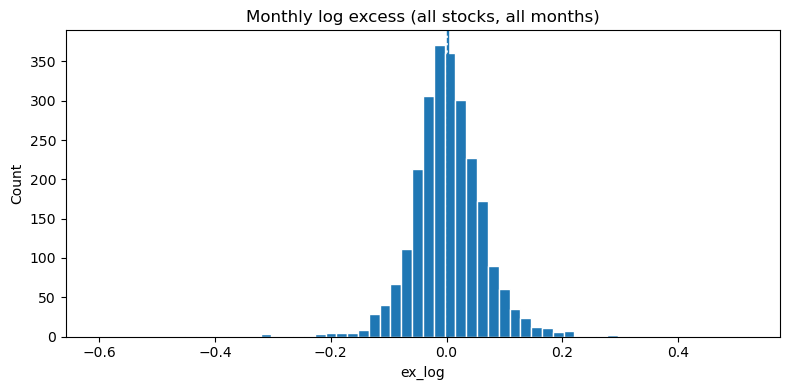

n=2480, mean=0.0022, std=0.0628, min=-0.601, max=0.520


In [27]:
# Plot histogram of ex_log 
ex_log = returns_monthly['ex_log']
x = ex_log[np.isfinite(ex_log)] 

plt.figure(figsize=(8,4))
plt.hist(x, bins=60, edgecolor='white')
plt.axvline(0, linestyle='--', linewidth=1)          
plt.axvline(x.mean(), linestyle='-', linewidth=1)    

plt.title("Monthly log excess (all stocks, all months)")
plt.xlabel("ex_log")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"n={len(x)}, mean={x.mean():.4f}, std={x.std():.4f}, "
      f"min={x.min():.3f}, max={x.max():.3f}")


In [36]:
# Benchmark statistics for the indices
g = returns_monthly.groupby('bench')['ex_log']
stats = g.agg(mean='mean', median='median', std='std', count='size')
# View of the location stats
stats[['mean','median_simple_%']] = pd.concat(
    [stats['mean'], np.expm1(g.median())*100], axis=1
)
print(stats)


           mean    median       std  count  median_simple_%
bench                                                      
^FTSE  0.001057 -0.000230  0.065555   1240        -0.022991
^GSPC  0.003265  0.000954  0.059991   1240         0.095426


In [38]:
# Check that all equities in the basket are correctly benchmarked to their respective market
uk_mask = returns_monthly['ticker'].astype(str).str.endswith('.L')

# All UK rows mapped to ^FTSE, all US rows to ^GSPC?
bad_uk = returns_monthly.loc[uk_mask & (returns_monthly['bench'] != '^FTSE')]
bad_us = returns_monthly.loc[~uk_mask & (returns_monthly['bench'] != '^GSPC')]
print("UK mis-maps:", len(bad_uk), " | US mis-maps:", len(bad_us))

# Any ticker mapped to more than one bench?
multi_bench = returns_monthly.groupby('ticker')['bench'].nunique()
print("Tickers with >1 benchmark:\n", multi_bench[multi_bench > 1])


UK mis-maps: 0  | US mis-maps: 0
Tickers with >1 benchmark:
 Series([], Name: bench, dtype: int64)
